<a href="https://colab.research.google.com/github/ianelgar40/IansMIS433/blob/main/QB_winnning_percentage_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("openai") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "openai"])

import getpass
import io
import json
import os
import re
import textwrap
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.3f}".format)

RANDOM_STATE = 42
SEASON = 2024

In [ ]:
# Source URLs.

PLAYER_STATS_URL = "https://github.com/nflverse/nflverse-data/releases/download/player_stats/stats_player_week_2024.csv"

# The nflreadr R function uses the historical_contracts asset. In many environments,
# the compressed CSV is the most reliable direct download for pandas.
CONTRACT_URLS = [
    "https://github.com/nflverse/nflverse-data/releases/download/contracts/historical_contracts.csv.gz",
    "https://github.com/nflverse/nflverse-data/releases/download/contracts/historical_contracts.csv",
]



def read_csv_first_available(urls, label):
    """Try several URLs and return the first CSV that loads successfully."""
    last_error = None
    for url in urls:
        try:
            print(f"Loading {label}: {url}")
            return pd.read_csv(url, low_memory=False)
        except Exception as exc:
            print(f"Could not load {url}: {exc}")
            last_error = exc
    raise RuntimeError(f"Unable to load {label}. Last error: {last_error}")


player_stats_raw = pd.read_csv(PLAYER_STATS_URL, low_memory=False)
contracts_raw = read_csv_first_available(CONTRACT_URLS, "contract salary data")

print("Player stats shape:", player_stats_raw.shape)
print("Contracts shape:", contracts_raw.shape)

display(player_stats_raw.head())
display(contracts_raw.head())

Loading contract salary data: https://github.com/nflverse/nflverse-data/releases/download/contracts/historical_contracts.csv.gz
Player stats shape: (18981, 114)
Contracts shape: (31893, 24)


,player_id,player_name,player_display_name,position,position_group,headshot_url,season,week,season_type,team,opponent_team,completions,attempts,passing_yards,passing_tds,passing_interceptions,sacks_suffered,sack_yards_lost,sack_fumbles,sack_fumbles_lost,passing_air_yards,passing_yards_after_catch,passing_first_downs,passing_epa,passing_cpoe,passing_2pt_conversions,pacr,carries,rushing_yards,rushing_tds,rushing_fumbles,rushing_fumbles_lost,rushing_first_downs,rushing_epa,rushing_2pt_conversions,receptions,targets,receiving_yards,receiving_tds,receiving_fumbles,receiving_fumbles_lost,receiving_air_yards,receiving_yards_after_catch,receiving_first_downs,receiving_epa,receiving_2pt_conversions,racr,target_share,air_yards_share,wopr,special_teams_tds,def_tackles_solo,def_tackles_with_assist,def_tackle_assists,def_tackles_for_loss,def_tackles_for_loss_yards,def_fumbles_forced,def_sacks,def_sack_yards,def_qb_hits,def_interceptions,def_interception_yards,def_pass_defended,def_tds,def_fumbles,def_safeties,misc_yards,fumble_recovery_own,fumble_recovery_yards_own,fumble_recovery_opp,fumble_recovery_yards_opp,fumble_recovery_tds,penalties,penalty_yards,punt_returns,punt_return_yards,kickoff_returns,kickoff_return_yards,fg_made,fg_att,fg_missed,fg_blocked,fg_long,fg_pct,fg_made_0_19,fg_made_20_29,fg_made_30_39,fg_made_40_49,fg_made_50_59,fg_made_60_,fg_missed_0_19,fg_missed_20_29,fg_missed_30_39,fg_missed_40_49,fg_missed_50_59,fg_missed_60_,fg_made_list,fg_missed_list,fg_blocked_list,fg_made_distance,fg_missed_distance,fg_blocked_distance,pat_made,pat_att,pat_missed,pat_blocked,pat_pct,gwfg_made,gwfg_att,gwfg_missed,gwfg_blocked,gwfg_distance,fantasy_points,fantasy_points_ppr
0,00-0023459,A.Rodgers,Aaron Rodgers,QB,QB,https://static.www.nfl.com/image/upload/f_auto...,2024,1,REG,NYJ,SF,13,21,167,1,1,1,-5,0,0,164,93,8,3.258,-5.898,0,1.018,1,-1,0,0,0,0,0.000,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,0.000,0.000,0.000,0,0,0,0,0,0,0,0.000,0.000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,0,0,0,0,0,0,NaN,0,0,0,0,0,8.580,8.580
1,00-0023853,M.Prater,Matt Prater,K,SPEC,https://static.www.nfl.com/image/upload/f_auto...,2024,1,REG,ARI,BUF,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,NaN,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,0.000,0.000,0.000,0,0,0,0,0,0,0,0.000,0.000,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,2,2,0,0,31.000,1.000,0,1,1,0,0,0,0,0,0,0,0,0,29;31,NaN,NaN,60,0,0,2,2,0,0,1.000,0,0,0,0,0,0.000,0.000
2,00-0025565,N.Folk,Nick Folk,K,SPEC,https://static.www.nfl.com/image/upload/f_auto...,2024,1,REG,TEN,CHI,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,NaN,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,0.000,0.000,0.000,0,0,0,0,0,0,0,0.000,0.000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,40.000,1.000,0,0,0,1,0,0,0,0,0,0,0,0,40,NaN,NaN,40,0,0,2,2,0,0,1.000,0,0,0,0,0,0.000,0.000
3,00-0026190,C.Campbell,Calais Campbell,DE,DL,https://static.www.nfl.com/image/upload/f_auto...,2024,1,REG,MIA,JAX,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,NaN,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,0.000,0.000,0.000,0,3,0,0,2,14,0,1.000,13.000,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,0,0,0,0,0,0,NaN,0,0,0,0,0,0.000,0.000
4,00-0026498,M.Stafford,Matthew Stafford,QB,QB,https://static.www.nfl.com/image/upload/f_auto...,2024,1,REG,LA,DET,34,49,317,1,1,2,-13,0,0,290,171,15,4.536,0.365,0,1.093,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,0.000,0.000,0.000,0,0,0,0,0,0,0,0.000,0.000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,0,0,0,0,0,0,NaN,0,0,0,0,0,14.680,14.680


,player,position,team,is_active,year_signed,years,value,apy,guaranteed,apy_cap_pct,inflated_value,inflated_apy,inflated_guaranteed,player_page,otc_id,date_of_birth,height,weight,college,draft_year,draft_round,draft_overall,draft_team,season_history
0,Aaron Rodgers,QB,Packers,True,2022,5.000,150815000,50271667,150665000,0.241,150815000,50271667,150665000,https://overthecap.com/player/aaron-rodgers/1085/,1085,NaN,"6'2""",225.000,California,"2,005.000",1.000,24.000,Packers,NaN
1,Josh Allen,QB,Bills,True,2021,6.000,258000000,43000000,150000000,0.236,294332055,49055342,171123288,https://overthecap.com/player/josh-allen/6892/,6892,NaN,"6'5""",233.000,Wyoming,"2,018.000",1.000,7.000,Bills,NaN
2,Patrick Mahomes,QB,Chiefs,True,2020,10.000,450000000,45000000,141000000,0.227,472704339,47270434,148114026,https://overthecap.com/player/patrick-mahomes/...,5594,NaN,"6'2""",225.000,Texas Tech,"2,017.000",1.000,10.000,Chiefs,NaN
3,Deshaun Watson,QB,Browns,True,2022,5.000,230000000,46000000,230000000,0.221,230000000,46000000,230000000,https://overthecap.com/player/deshaun-watson/5...,5596,NaN,"6'2""",221.000,Clemson,"2,017.000",1.000,12.000,Texans,NaN
4,Dak Prescott,QB,Cowboys,True,2021,4.000,160000000,40000000,126000000,0.219,182531507,45632877,143743562,https://overthecap.com/player/dak-prescott/4848/,4848,NaN,"6'2""",226.000,Mississippi State,"2,016.000",4.000,135.000,Cowboys,NaN


In [ ]:
import pandas as pd
from IPython.display import display

GAMES_URL = "https://raw.githubusercontent.com/nflverse/nfldata/master/data/games.csv"

games_raw = pd.read_csv(GAMES_URL, low_memory=False)

print("Games data shape:", games_raw.shape)
display(games_raw.head())

Games data shape: (7548, 46)


,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,old_game_id,gsis,nfl_detail_id,pfr,pff,espn,ftn,away_rest,home_rest,away_moneyline,home_moneyline,spread_line,away_spread_odds,home_spread_odds,total_line,under_odds,over_odds,div_game,roof,surface,temp,wind,away_qb_id,home_qb_id,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium_id,stadium
0,1999_01_MIN_ATL,1999,REG,1,1999-09-12,Sunday,NaN,MIN,17.000,ATL,14.000,Home,-3.000,31.000,0.000,1999091210,598.000,NaN,199909120atl,NaN,"190,912,001.000",NaN,7,7,NaN,NaN,-4.000,NaN,NaN,49.000,NaN,NaN,0,dome,astroturf,NaN,NaN,00-0003761,00-0002876,Randall Cunningham,Chris Chandler,Dennis Green,Dan Reeves,Gerry Austin,ATL00,Georgia Dome
1,1999_01_KC_CHI,1999,REG,1,1999-09-12,Sunday,NaN,KC,17.000,CHI,20.000,Home,3.000,37.000,0.000,1999091206,597.000,NaN,199909120chi,NaN,"190,912,003.000",NaN,7,7,NaN,NaN,-3.000,NaN,NaN,38.000,NaN,NaN,0,outdoors,grass,80.000,12.000,00-0006300,00-0010560,Elvis Grbac,Shane Matthews,Gunther Cunningham,Dick Jauron,Phil Luckett,CHI98,Soldier Field
2,1999_01_PIT_CLE,1999,REG,1,1999-09-12,Sunday,NaN,PIT,43.000,CLE,0.000,Home,-43.000,43.000,0.000,1999091213,604.000,NaN,199909120cle,NaN,"190,912,005.000",NaN,7,7,NaN,NaN,-6.000,NaN,NaN,37.000,NaN,NaN,1,outdoors,grass,78.000,12.000,00-0015700,00-0004230,Kordell Stewart,Ty Detmer,Bill Cowher,Chris Palmer,Bob McElwee,CLE00,Cleveland Browns Stadium
3,1999_01_OAK_GB,1999,REG,1,1999-09-12,Sunday,NaN,OAK,24.000,GB,28.000,Home,4.000,52.000,0.000,1999091208,602.000,NaN,199909120gnb,NaN,"190,912,009.000",NaN,7,7,NaN,NaN,9.000,NaN,NaN,43.000,NaN,NaN,0,outdoors,grass,67.000,10.000,00-0005741,00-0005106,Rich Gannon,Brett Favre,Jon Gruden,Ray Rhodes,Tony Corrente,GNB00,Lambeau Field
4,1999_01_BUF_IND,1999,REG,1,1999-09-12,Sunday,NaN,BUF,14.000,IND,31.000,Home,17.000,45.000,0.000,1999091202,591.000,NaN,199909120clt,NaN,"190,912,011.000",NaN,7,7,NaN,NaN,-3.000,NaN,NaN,45.500,NaN,NaN,1,dome,astroturf,NaN,NaN,00-0005363,00-0010346,Doug Flutie,Peyton Manning,Wade Phillips,Jim Mora,Ron Blum,IND99,RCA Dome


In [ ]:
columns_to_drop = [
    'weekday', 'gametime', 'location', 'total', 'overtime', 'old_game_id',
    'gsis', 'nfl_detail_id', 'pfr', 'pff', 'espn', 'ftn', 'away_rest', 'home_rest',
    'away_moneyline', 'home_moneyline', 'spread_line', 'away_spread_odds',
    'home_spread_odds', 'total_line', 'under_odds', 'over_odds', 'div_game',
    'roof', 'surface', 'temp', 'wind', 'away_coach', 'home_coach', 'referee',
    'stadium_id', 'stadium'
]

# Filter columns to drop to only include those that actually exist in the DataFrame
existing_columns_to_drop = [col for col in columns_to_drop if col in games_raw.columns]

games_raw = games_raw.drop(columns=existing_columns_to_drop)

print("Games data shape after dropping columns:", games_raw.shape)
display(games_raw.head())

Games data shape after dropping columns: (7548, 14)


,game_id,season,game_type,week,gameday,away_team,away_score,home_team,home_score,result,away_qb_id,home_qb_id,away_qb_name,home_qb_name
0,1999_01_MIN_ATL,1999,REG,1,1999-09-12,MIN,17.000,ATL,14.000,-3.000,00-0003761,00-0002876,Randall Cunningham,Chris Chandler
1,1999_01_KC_CHI,1999,REG,1,1999-09-12,KC,17.000,CHI,20.000,3.000,00-0006300,00-0010560,Elvis Grbac,Shane Matthews
2,1999_01_PIT_CLE,1999,REG,1,1999-09-12,PIT,43.000,CLE,0.000,-43.000,00-0015700,00-0004230,Kordell Stewart,Ty Detmer
3,1999_01_OAK_GB,1999,REG,1,1999-09-12,OAK,24.000,GB,28.000,4.000,00-0005741,00-0005106,Rich Gannon,Brett Favre
4,1999_01_BUF_IND,1999,REG,1,1999-09-12,BUF,14.000,IND,31.000,17.000,00-0005363,00-0010346,Doug Flutie,Peyton Manning


In [ ]:
# Player Stats for 1999-2024
player_stats_dfs = []
start_year = 1999
end_year = 2024

print(f"Loading player stats data from {start_year} to {end_year}...")
for year in range(start_year, end_year + 1):
    yearly_player_stats_url = f"https://github.com/nflverse/nflverse-data/releases/download/player_stats/stats_player_week_{year}.csv"
    try:
        print(f"  Loading player stats for year: {year}")
        df = pd.read_csv(yearly_player_stats_url, low_memory=False)
        player_stats_dfs.append(df)
    except Exception as e:
        print(f"  Could not load player stats for {year}: {e}")

if player_stats_dfs:
    player_stats_raw = pd.concat(player_stats_dfs, ignore_index=True)
    print("Combined player stats shape:", player_stats_raw.shape)
    display(player_stats_raw.head())
else:
    print("No player stats data loaded for the specified range.")

# Contracts Data - filtered for 1999-2024
print(f"Loading and filtering contract data for year_signed from {start_year} to {end_year}...")
# Assuming CONTRACT_URLS and read_csv_first_available are available from previous cells.
contracts_raw = read_csv_first_available(CONTRACT_URLS, "contract salary data")
contracts_raw = contracts_raw[(contracts_raw['year_signed'] >= start_year) & (contracts_raw['year_signed'] <= end_year)].copy()

print("Filtered contracts shape:", contracts_raw.shape)
display(contracts_raw.head())

Loading player stats data from 1999 to 2024...
  Loading player stats for year: 1999
  Loading player stats for year: 2000
  Loading player stats for year: 2001
  Loading player stats for year: 2002
  Could not load player stats for 2002: HTTP Error 404: Not Found
  Loading player stats for year: 2003
  Loading player stats for year: 2004
  Loading player stats for year: 2005
  Loading player stats for year: 2006
  Loading player stats for year: 2007
  Loading player stats for year: 2008
  Loading player stats for year: 2009
  Loading player stats for year: 2010
  Loading player stats for year: 2011
  Loading player stats for year: 2012
  Loading player stats for year: 2013
  Loading player stats for year: 2014
  Loading player stats for year: 2015
  Loading player stats for year: 2016
  Loading player stats for year: 2017
  Loading player stats for year: 2018
  Loading player stats for year: 2019
  Could not load player stats for 2019: HTTP Error 404: Not Found
  Loading player stats 

,player_id,player_name,player_display_name,position,position_group,headshot_url,season,week,season_type,team,opponent_team,completions,attempts,passing_yards,passing_tds,passing_interceptions,sacks_suffered,sack_yards_lost,sack_fumbles,sack_fumbles_lost,passing_air_yards,passing_yards_after_catch,passing_first_downs,passing_epa,passing_cpoe,passing_2pt_conversions,pacr,carries,rushing_yards,rushing_tds,rushing_fumbles,rushing_fumbles_lost,rushing_first_downs,rushing_epa,rushing_2pt_conversions,receptions,targets,receiving_yards,receiving_tds,receiving_fumbles,receiving_fumbles_lost,receiving_air_yards,receiving_yards_after_catch,receiving_first_downs,receiving_epa,receiving_2pt_conversions,racr,target_share,air_yards_share,wopr,special_teams_tds,def_tackles_solo,def_tackles_with_assist,def_tackle_assists,def_tackles_for_loss,def_tackles_for_loss_yards,def_fumbles_forced,def_sacks,def_sack_yards,def_qb_hits,def_interceptions,def_interception_yards,def_pass_defended,def_tds,def_fumbles,def_safeties,misc_yards,fumble_recovery_own,fumble_recovery_yards_own,fumble_recovery_opp,fumble_recovery_yards_opp,fumble_recovery_tds,penalties,penalty_yards,punt_returns,punt_return_yards,kickoff_returns,kickoff_return_yards,fg_made,fg_att,fg_missed,fg_blocked,fg_long,fg_pct,fg_made_0_19,fg_made_20_29,fg_made_30_39,fg_made_40_49,fg_made_50_59,fg_made_60_,fg_missed_0_19,fg_missed_20_29,fg_missed_30_39,fg_missed_40_49,fg_missed_50_59,fg_missed_60_,fg_made_list,fg_missed_list,fg_blocked_list,fg_made_distance,fg_missed_distance,fg_blocked_distance,pat_made,pat_att,pat_missed,pat_blocked,pat_pct,gwfg_made,gwfg_att,gwfg_missed,gwfg_blocked,gwfg_distance,fantasy_points,fantasy_points_ppr
0,0,NaN,NaN,NaN,NaN,NaN,1999,1,REG,ATL,MIN,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,NaN,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,0.000,NaN,NaN,0.000,1,0,0,0,0,1,1.000,15.000,0,0,0,0,0.000,0.000,2,0,0,0,0,0,0,14,81,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,0,0,0,0,0,0,NaN,0,0,0,0,0,0.000,0.000
1,00-0000003,A.al-Jabbar,Abdul-Karim al-Jabbar,RB,RB,NaN,1999,1,REG,MIA,DEN,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,NaN,16,60,1,0,0,4,6.249,0,1,1,7,0,0,0,0,0,0,0.292,0,0.000,0.045,NaN,NaN,0.000,0,0,0,0,0,0,0.000,0.000,0,0,0,0,0.000,0.000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,0,0,0,0,0,0,NaN,0,0,0,0,0,12.700,13.700
2,00-0000007,R.Abdullah,Rabih Abdullah,RB,RB,NaN,1999,1,REG,TB,NYG,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,NaN,1,0,0,0,0,0,-0.383,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,0.000,0.000,0.000,0.000,0,0,0,0,0,0,0.000,0.000,0,0,0,0,0.000,0.000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,0,0,0,0,0,0,NaN,0,0,0,0,0,0.000,0.000
3,00-0000008,R.Abdullah,Rahim Abdullah,OLB,LB,NaN,1999,1,REG,CLE,PIT,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,NaN,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,0.000,0.000,0.000,0.000,3,0,1,0,0,0,0.000,0.000,0,0,0,1,0.000,0.000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,0,0,0,0,0,0,NaN,0,0,0,0,0,0.000,0.000
4,00-0000017,D.Abraham,Donnie Abraham,CB,DB,NaN,1999,1,REG,TB,NYG,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,NaN,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,0.000,0.000,0.000,0.000,1,3,2,0,0,0,0.000,0.000,0,0,0,1,0.000,0.000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,0,0,0,0,0,0,NaN,0,0,0,0,0,0.000,0.000


Loading and filtering contract data for year_signed from 1999 to 2024...
Loading contract salary data: https://github.com/nflverse/nflverse-data/releases/download/contracts/historical_contracts.csv.gz
Filtered contracts shape: (30651, 24)


,player,position,team,is_active,year_signed,years,value,apy,guaranteed,apy_cap_pct,inflated_value,inflated_apy,inflated_guaranteed,player_page,otc_id,date_of_birth,height,weight,college,draft_year,draft_round,draft_overall,draft_team,season_history
0,Aaron Rodgers,QB,Packers,True,2022,5.000,150815000,50271667,150665000,0.241,150815000,50271667,150665000,https://overthecap.com/player/aaron-rodgers/1085/,1085,NaN,"6'2""",225.000,California,"2,005.000",1.000,24.000,Packers,NaN
1,Josh Allen,QB,Bills,True,2021,6.000,258000000,43000000,150000000,0.236,294332055,49055342,171123288,https://overthecap.com/player/josh-allen/6892/,6892,NaN,"6'5""",233.000,Wyoming,"2,018.000",1.000,7.000,Bills,NaN
2,Patrick Mahomes,QB,Chiefs,True,2020,10.000,450000000,45000000,141000000,0.227,472704339,47270434,148114026,https://overthecap.com/player/patrick-mahomes/...,5594,NaN,"6'2""",225.000,Texas Tech,"2,017.000",1.000,10.000,Chiefs,NaN
3,Deshaun Watson,QB,Browns,True,2022,5.000,230000000,46000000,230000000,0.221,230000000,46000000,230000000,https://overthecap.com/player/deshaun-watson/5...,5596,NaN,"6'2""",221.000,Clemson,"2,017.000",1.000,12.000,Texans,NaN
4,Dak Prescott,QB,Cowboys,True,2021,4.000,160000000,40000000,126000000,0.219,182531507,45632877,143743562,https://overthecap.com/player/dak-prescott/4848/,4848,NaN,"6'2""",226.000,Mississippi State,"2,016.000",4.000,135.000,Cowboys,NaN


In [ ]:
player_stats_qb = player_stats_raw[player_stats_raw['position'] == 'QB'].copy()

columns_to_drop_qb = [
    'headshot_url', 'passing_epa', 'passing_cpoe', 'passing_2pt_conversions',
    'pacr', 'rushing_epa', 'rushing_2pt_conversions', 'receptions', 'targets',
    'receiving_yards', 'receiving_tds', 'receiving_fumbles', 'receiving_fumbles_lost',
    'receiving_air_yards', 'receiving_yards_after_catch', 'receiving_first_downs',
    'receiving_epa', 'receiving_2pt_conversions', 'racr', 'target_share',
    'air_yards_share', 'wopr', 'special_teams_tds', 'def_tackles_solo',
    'def_tackles_with_assist', 'def_tackle_assists', 'def_tackles_for_loss',
    'def_tackles_for_loss_yards', 'def_fumbles_forced', 'def_sacks',
    'def_sack_yards', 'def_qb_hits', 'def_interceptions', 'def_interception_yards',
    'def_pass_defended', 'def_tds', 'def_fumbles', 'def_safeties', 'misc_yards',
    'fumble_recovery_own', 'fumble_recovery_yards_own', 'fumble_recovery_opp',
    'fumble_recovery_yards_opp', 'fumble_recovery_tds', 'penalties',
    'penalty_yards', 'punt_returns', 'punt_return_yards', 'kickoff_returns',
    'kickoff_return_yards', 'fg_made', 'fg_att', 'fg_missed', 'fg_blocked',
    'fg_long', 'fg_pct', 'fg_made_0_19', 'fg_made_20_29', 'fg_made_30_39',
    'fg_made_40_49', 'fg_made_50_59', 'fg_made_60_', 'fg_missed_0_19',
    'fg_missed_20_29', 'fg_missed_30_39', 'fg_missed_40_49', 'fg_missed_50_59',
    'fg_missed_60_', 'fg_made_list', 'fg_missed_list', 'fg_blocked_list',
    'fg_made_distance', 'fg_missed_distance', 'fg_blocked_distance', 'pat_made',
    'pat_att', 'pat_missed', 'pat_blocked', 'pat_pct', 'gwfg_made', 'gwfg_att',
    'gwfg_missed', 'gwfg_blocked', 'gwfg_distance', 'fantasy_points',
    'fantasy_points_ppr'
]

# Filter columns to drop to only include those that actually exist in the DataFrame
existing_columns_to_drop_qb = [col for col in columns_to_drop_qb if col in player_stats_qb.columns]

player_stats_qb = player_stats_qb.drop(columns=existing_columns_to_drop_qb)

print("QB Player stats shape after filtering and dropping columns:", player_stats_qb.shape)
display(player_stats_qb.head())

QB Player stats shape after filtering and dropping columns: (15527, 28)


,player_id,player_name,player_display_name,position,position_group,season,week,season_type,team,opponent_team,completions,attempts,passing_yards,passing_tds,passing_interceptions,sacks_suffered,sack_yards_lost,sack_fumbles,sack_fumbles_lost,passing_air_yards,passing_yards_after_catch,passing_first_downs,carries,rushing_yards,rushing_tds,rushing_fumbles,rushing_fumbles_lost,rushing_first_downs
8,00-0000104,T.Aikman,Troy Aikman,QB,QB,1999,1,REG,DAL,WAS,28,49,362,5,3,1,-7,0,0,39,362,15,2,4,0,0,0,1
52,00-0000865,C.Batch,Charlie Batch,QB,QB,1999,1,REG,DET,SEA,16,26,216,3,1,5,-14,0,0,3,216,10,3,-3,0,0,0,0
69,00-0001218,S.Beuerlein,Steve Beuerlein,QB,QB,1999,1,REG,CAR,NO,16,32,207,1,1,7,-46,1,1,4,207,9,1,8,0,0,0,0
78,00-0001335,J.Blake,Jeff Blake,QB,QB,1999,1,REG,CIN,TEN,18,31,182,2,2,1,0,0,0,29,182,13,11,90,0,1,0,7
79,00-0001361,D.Bledsoe,Drew Bledsoe,QB,QB,1999,1,REG,NE,NYJ,21,30,340,1,1,2,-14,1,1,7,340,13,1,-1,0,0,0,0


In [ ]:
# Merge when the QB's team is the home team
qb_home_games = pd.merge(
    player_stats_qb,
    games_raw,
    left_on=['season', 'week', 'team', 'opponent_team'],
    right_on=['season', 'week', 'home_team', 'away_team'],
    how='inner',
    suffixes=('_player', '_game')
)

# Merge when the QB's team is the away team
qb_away_games = pd.merge(
    player_stats_qb,
    games_raw,
    left_on=['season', 'week', 'team', 'opponent_team'],
    right_on=['season', 'week', 'away_team', 'home_team'],
    how='inner',
    suffixes=('_player', '_game')
)

# Combine the merged dataframes
qb_game_stats = pd.concat([qb_home_games, qb_away_games], ignore_index=True)

print("Combined QB stats with game data shape:", qb_game_stats.shape)
display(qb_game_stats.head())

Combined QB stats with game data shape: (13589, 40)


,player_id,player_name,player_display_name,position,position_group,season,week,season_type,team,opponent_team,completions,attempts,passing_yards,passing_tds,passing_interceptions,sacks_suffered,sack_yards_lost,sack_fumbles,sack_fumbles_lost,passing_air_yards,passing_yards_after_catch,passing_first_downs,carries,rushing_yards,rushing_tds,rushing_fumbles,rushing_fumbles_lost,rushing_first_downs,game_id,game_type,gameday,away_team,away_score,home_team,home_score,result,away_qb_id,home_qb_id,away_qb_name,home_qb_name
0,00-0002110,M.Brunell,Mark Brunell,QB,QB,1999,1,REG,JAX,SF,22,30,265,1,0,2,-18,0,0,0,265,11,2,12,0,0,0,1,1999_01_SF_JAX,REG,1999-09-12,SF,3.000,JAX,41.000,38.000,00-0018441,00-0002110,Steve Young,Mark Brunell
1,00-0002876,C.Chandler,Chris Chandler,QB,QB,1999,1,REG,ATL,MIN,17,30,258,1,0,2,-12,1,1,0,258,15,3,21,0,0,0,1,1999_01_MIN_ATL,REG,1999-09-12,MIN,17.000,ATL,14.000,-3.000,00-0003761,00-0002876,Randall Cunningham,Chris Chandler
2,00-0003535,T.Couch,Tim Couch,QB,QB,1999,1,REG,CLE,PIT,0,3,0,0,1,1,-7,1,1,12,0,0,0,0,0,0,0,0,1999_01_PIT_CLE,REG,1999-09-12,PIT,43.000,CLE,0.000,-43.000,00-0015700,00-0004230,Kordell Stewart,Ty Detmer
3,00-0004230,T.Detmer,Ty Detmer,QB,QB,1999,1,REG,CLE,PIT,6,13,52,0,1,2,-14,0,0,12,52,2,1,-1,0,0,0,0,1999_01_PIT_CLE,REG,1999-09-12,PIT,43.000,CLE,0.000,-43.000,00-0015700,00-0004230,Kordell Stewart,Ty Detmer
4,00-0004293,T.Dilfer,Trent Dilfer,QB,QB,1999,1,REG,TB,NYG,15,31,174,1,3,2,-11,1,1,36,174,11,1,4,0,0,0,0,1999_01_NYG_TB,REG,1999-09-12,NYG,17.000,TB,13.000,-4.000,00-0006212,00-0004293,Kent Graham,Trent Dilfer


In [ ]:
qb_game_stats['win'] = 0

# If the QB's team is the home team and result_game is positive, it's a win
qbs_at_home_win = (qb_game_stats['team'] == qb_game_stats['home_team']) & (qb_game_stats['result'] > 0)
qb_game_stats.loc[qbs_at_home_win, 'win'] = 1

# If the QB's team is the away team and result_game is negative, it's an away win
qbs_away_win = (qb_game_stats['team'] == qb_game_stats['away_team']) & (qb_game_stats['result'] < 0)
qb_game_stats.loc[qbs_away_win, 'win'] = 1

# Drop specified columns
columns_to_drop_final = ['player_name', 'position_group', 'season_type', 'away_qb_id', 'home_qb_id', 'game_id']
existing_columns_to_drop_final = [col for col in columns_to_drop_final if col in qb_game_stats.columns]
qb_game_stats = qb_game_stats.drop(columns=existing_columns_to_drop_final)

print("QB Game Stats with 'win' column shape:", qb_game_stats.shape)
display(qb_game_stats.head())

QB Game Stats with 'win' column shape: (13589, 35)


,player_id,player_display_name,position,season,week,team,opponent_team,completions,attempts,passing_yards,passing_tds,passing_interceptions,sacks_suffered,sack_yards_lost,sack_fumbles,sack_fumbles_lost,passing_air_yards,passing_yards_after_catch,passing_first_downs,carries,rushing_yards,rushing_tds,rushing_fumbles,rushing_fumbles_lost,rushing_first_downs,game_type,gameday,away_team,away_score,home_team,home_score,result,away_qb_name,home_qb_name,win
0,00-0002110,Mark Brunell,QB,1999,1,JAX,SF,22,30,265,1,0,2,-18,0,0,0,265,11,2,12,0,0,0,1,REG,1999-09-12,SF,3.000,JAX,41.000,38.000,Steve Young,Mark Brunell,1
1,00-0002876,Chris Chandler,QB,1999,1,ATL,MIN,17,30,258,1,0,2,-12,1,1,0,258,15,3,21,0,0,0,1,REG,1999-09-12,MIN,17.000,ATL,14.000,-3.000,Randall Cunningham,Chris Chandler,0
2,00-0003535,Tim Couch,QB,1999,1,CLE,PIT,0,3,0,0,1,1,-7,1,1,12,0,0,0,0,0,0,0,0,REG,1999-09-12,PIT,43.000,CLE,0.000,-43.000,Kordell Stewart,Ty Detmer,0
3,00-0004230,Ty Detmer,QB,1999,1,CLE,PIT,6,13,52,0,1,2,-14,0,0,12,52,2,1,-1,0,0,0,0,REG,1999-09-12,PIT,43.000,CLE,0.000,-43.000,Kordell Stewart,Ty Detmer,0
4,00-0004293,Trent Dilfer,QB,1999,1,TB,NYG,15,31,174,1,3,2,-11,1,1,36,174,11,1,4,0,0,0,0,REG,1999-09-12,NYG,17.000,TB,13.000,-4.000,Kent Graham,Trent Dilfer,0


In [ ]:
# Install / import OpenAI
import importlib.util
import subprocess
import sys
import os
import json
import pandas as pd

if importlib.util.find_spec("openai") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "openai"])

from openai import OpenAI
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

client = OpenAI()
print("OpenAI API key configured.")

def analyze_qb_game(qb_game_stats, season, week, qb_name=None, team=None):
    """
    Analyze one QB's performance for a selected NFL season and week.
    """
    game_df = qb_game_stats[
        (qb_game_stats["season"] == season) &
        (qb_game_stats["week"] == week)
    ].copy()

    if qb_name:
        name_cols = [c for c in game_df.columns if "name" in c.lower()]
        if len(name_cols) > 0:
            name_col = name_cols[0]
            game_df = game_df[
                game_df[name_col].astype(str).str.contains(qb_name, case=False, na=False)
            ]

    if team:
        game_df = game_df[game_df["team"].astype(str).str.upper() == team.upper()]

    if game_df.empty:
        return f"No QB game found for season {season}, week {week}."

    row = game_df.iloc[0]

    useful_cols = [
        "season", "week", "team", "opponent_team",
        "home_team", "away_team", "home_score", "away_score", "result", "win",
        "completions", "attempts", "passing_yards", "passing_tds",
        "passing_interceptions", "sacks_suffered", "sack_yards_lost",
        "passing_air_yards", "passing_yards_after_catch",
        "passing_first_downs",
        "carries", "rushing_yards", "rushing_tds",
        "rushing_first_downs",
        "rushing_fumbles", "rushing_fumbles_lost", 'player_display_name',
    ]

    available_cols = [c for c in useful_cols if c in game_df.columns]
    game_summary = row[available_cols].to_dict()

    prompt = f"Analyze this QB performance:\n{json.dumps(game_summary, indent=2)}"

    # Using the requested model gpt-4.1-mini
    response = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[
            {"role": "system", "content": "You are an NFL quarterback performance analyst."},
            {"role": "user", "content": prompt}
        ]
    )

    return response.choices[0].message.content

# Call the function correctly outside the definition scope
analysis = analyze_qb_game(
    qb_game_stats,
    season=2018,
    week=1,
    team="DEN"
)

print(analysis)

OpenAI API key configured.
Case Keenum's performance in Week 1 of the 2018 season for Denver against Seattle showed a combination of strong production and some risky plays:

- Completion rate: 25 completions on 39 attempts, approximately 64.1%, which is solid.
- Passing yards: 329 yards with 3 passing touchdowns, indicating effective downfield passing.
- Passing interceptions: 3 interceptions, which is a concern as it puts his team at risk multiple times.
- He had 366 passing air yards, meaning he threw deep or downfield quite a bit.
- The receivers gained 174 yards after the catch, meaning a good portion of the passing yards came from yards after catch, suggesting his passes allowed for yards gained after reception.
- 15 passing first downs demonstrates good effectiveness in sustaining drives.
- Sacked once for a 5-yard loss, relatively low for an NFL game.
- No rushing attempts or yards; his contribution was purely through the air.
- The team won 27-24 at home, so despite the interce

Top Predictors identified by Decision Tree:
passing_interceptions   0.307
rushing_yards           0.218
passing_tds             0.172
carries                 0.103
attempts                0.071
sack_yards_lost         0.065
passing_air_yards       0.040
sacks_suffered          0.024
dtype: float64


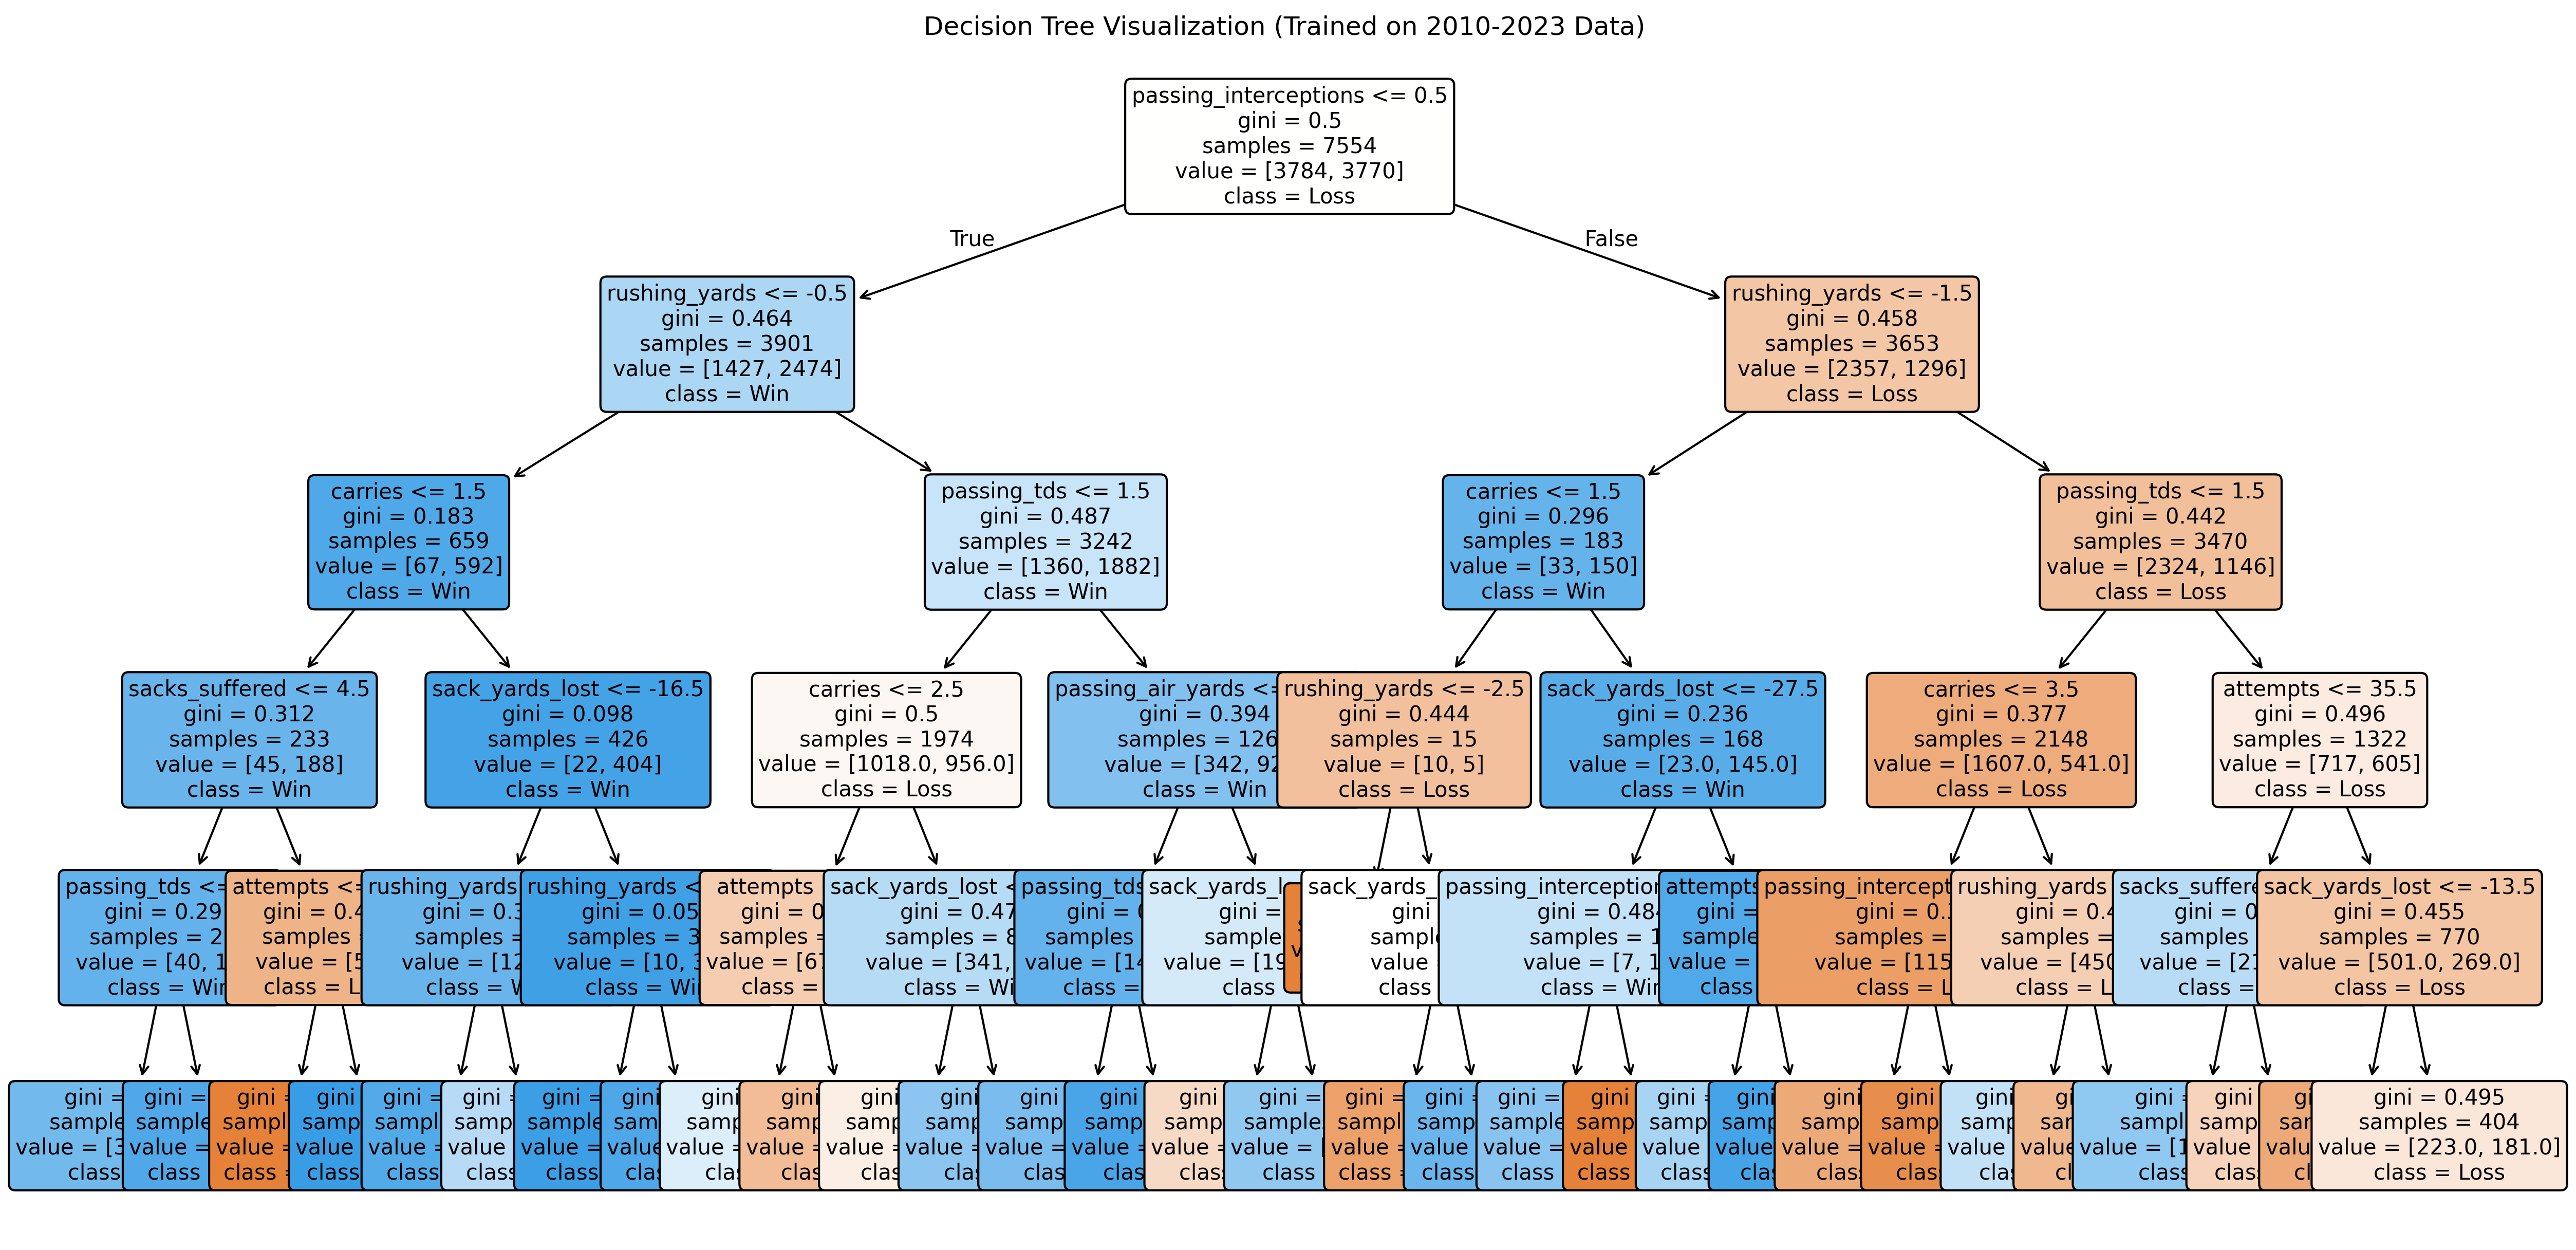

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 1. Prepare Features and Target
features = [
    'completions', 'attempts', 'passing_yards', 'passing_tds',
    'passing_interceptions', 'sacks_suffered', 'sack_yards_lost',
    'passing_air_yards', 'passing_yards_after_catch', 'carries',
    'rushing_yards', 'rushing_tds'
]

# Filter for relevant years and drop rows with missing feature values
ml_df = qb_game_stats.dropna(subset=features + ['win'])

# 2. Split Data: Training (2010-2023) and Test (2024)
train_df = ml_df[(ml_df['season'] >= 2010) & (ml_df['season'] <= 2023)]
test_df = ml_df[ml_df['season'] == 2024]

X_train = train_df[features]
y_train = train_df['win']
X_test = test_df[features]
y_test = test_df['win']

# 3. Train Decision Tree (limiting depth for visualization clarity)
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# 4. Predictors (Feature Importance)
importances = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False)
print("Top Predictors identified by Decision Tree:")
print(importances[importances > 0])

# 5. Visualization
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(20,10), dpi=300)
plot_tree(clf,
          feature_names=features,
          class_names=['Loss', 'Win'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree Visualization (Trained on 2010-2023 Data)")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Evaluate on Test Set (2024)
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy on 2024 Test Set: {accuracy:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Loss', 'Win']))

Accuracy on 2024 Test Set: 71.88%

Classification Report:
              precision    recall  f1-score   support

        Loss       0.71      0.75      0.73       348
         Win       0.73      0.69      0.71       349

    accuracy                           0.72       697
   macro avg       0.72      0.72      0.72       697
weighted avg       0.72      0.72      0.72       697



In [ ]:
from sklearn.metrics import cohen_kappa_score

# Calculate Cohen's Kappa to measure agreement above chance
kappa = cohen_kappa_score(y_test, y_pred)

print(f"Cohen's Kappa Coefficient: {kappa:.4f}")
print("\nInterpretation:")
if kappa <= 0:
    print("The model is performing no better (or worse) than random chance.")
elif kappa <= 0.4:
    print("The model shows fair to moderate agreement above chance.")
else:
    print("The model shows substantial agreement above chance.")

Cohen's Kappa Coefficient: 0.4376

Interpretation:
The model shows substantial agreement above chance.


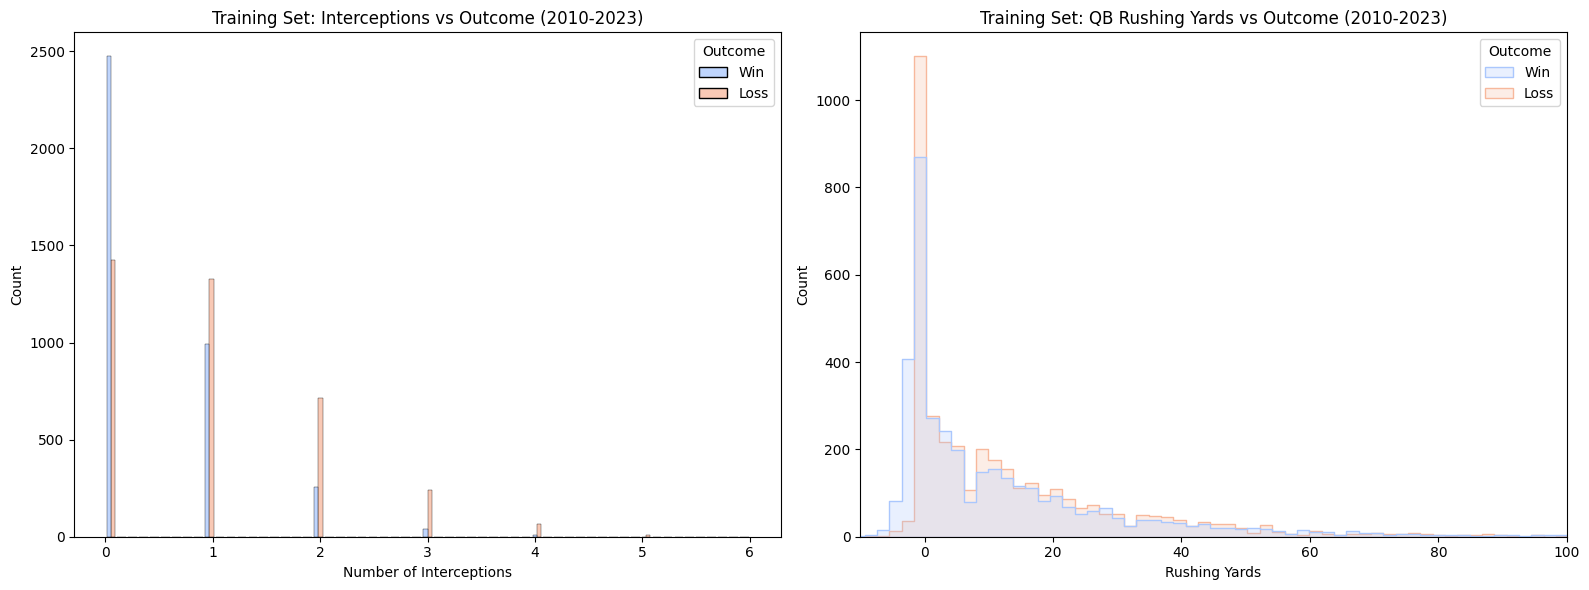

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare training data for visualization
plot_train_df = X_train.copy()
plot_train_df['Outcome'] = y_train.map({1: 'Win', 0: 'Loss'})

# Set up the figure for the two most impactful predictors in the training set
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Impact of Passing Interceptions (Training Set)
sns.histplot(data=plot_train_df, x='passing_interceptions', hue='Outcome',
             multiple='dodge', shrink=0.8, ax=axes[0], palette='coolwarm')
axes[0].set_title('Training Set: Interceptions vs Outcome (2010-2023)')
axes[0].set_xlabel('Number of Interceptions')

# 2. Impact of Rushing Yards (Training Set)
sns.histplot(data=plot_train_df, x='rushing_yards', hue='Outcome',
             element='step', ax=axes[1], palette='coolwarm')
axes[1].set_title('Training Set: QB Rushing Yards vs Outcome (2010-2023)')
axes[1].set_xlabel('Rushing Yards')
axes[1].set_xlim(-10, 100) # Focusing on the typical range for better visibility

plt.tight_layout()
plt.show()

/tmp/ipykernel_1733/375392258.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette=colors)


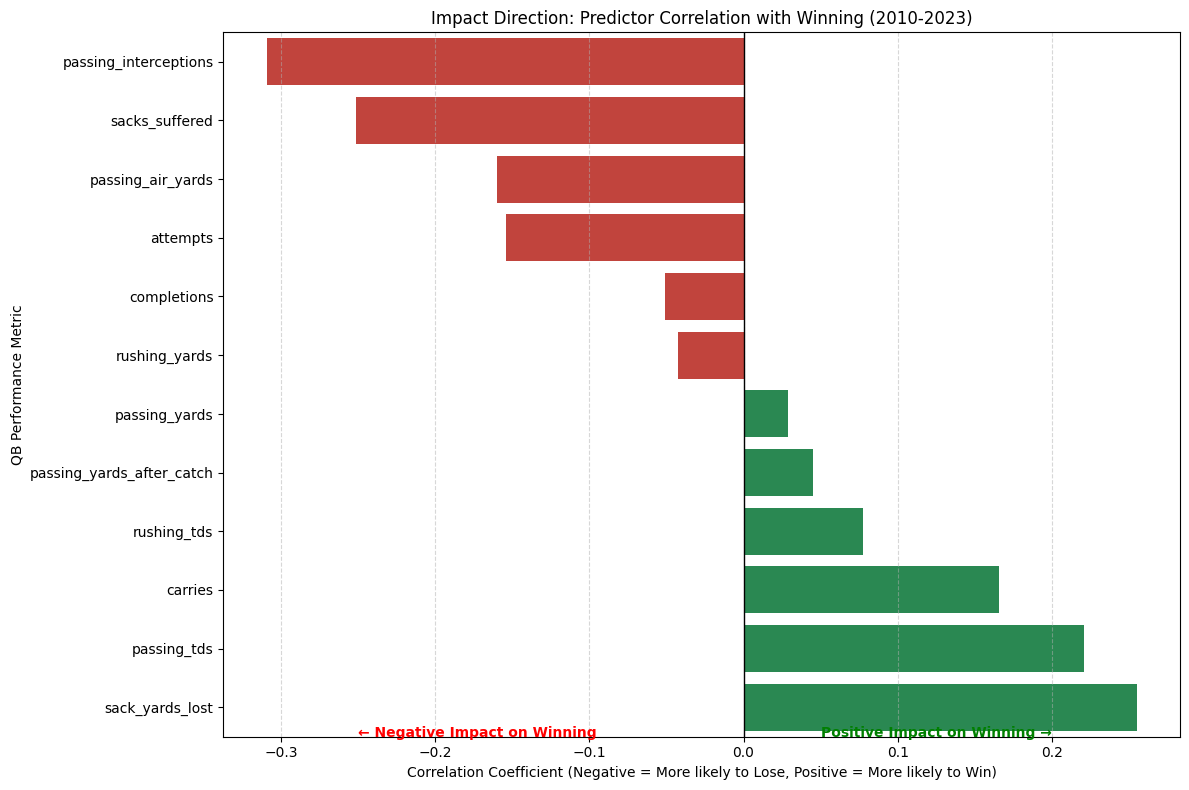

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a numeric win column for correlation calculation
plot_train_df['win_numeric'] = plot_train_df['Outcome'].map({'Win': 1, 'Loss': 0})

# Calculate correlation of features with the target 'win_numeric'
correlations = plot_train_df[features + ['win_numeric']].corr()['win_numeric'].drop('win_numeric').sort_values()

# Plotting the correlations
plt.figure(figsize=(12, 8))
colors = ['#d73027' if x < 0 else '#1a9850' for x in correlations]
sns.barplot(x=correlations.values, y=correlations.index, palette=colors)

plt.title('Impact Direction: Predictor Correlation with Winning (2010-2023)')
plt.xlabel('Correlation Coefficient (Negative = More likely to Lose, Positive = More likely to Win)')
plt.ylabel('QB Performance Metric')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Add annotations to explain the graph
plt.text(0.05, len(correlations)-0.5, 'Positive Impact on Winning →', color='green', fontweight='bold')
plt.text(-0.25, len(correlations)-0.5, '← Negative Impact on Winning', color='red', fontweight='bold')

plt.tight_layout()
plt.show()

### Investigating the 'Sack Yards Lost' Paradox

Usually, we expect sacks to be negative. However, in our correlation plot, `sack_yards_lost` shows a positive correlation with winning. This often suggests that QBs who are productive enough to win are also the ones who are droping back to pass more often, increasing their total opportunities to be sacked.

### Why is 'Sack Yards Lost' highly correlated with wins?

This is a classic example of **multicollinearity**. In the NFL, winning teams often have high passing volume. Since you can only lose yards to a sack if you are dropping back to pass, 'sack yards lost' scales upward with total passing attempts.

Even though individual sacks are bad, having *high total sack yardage* often means the QB was playing a long, high-volume game—which usually correlates with high-scoring wins.

### Interpreting Cohen's Kappa (0.4376)

Cohen's Kappa measures how much better the classifier performed than a **random classifier** that guesses based on the frequency of each class.

| Kappa Score | Strength of Agreement |
| :--- | :--- |
| < 0 | Poor (Worse than chance) |
| 0.01 – 0.20 | Slight |
| 0.21 – 0.40 | Fair |
| **0.41 – 0.60** | **Moderate / Substantial** |
| 0.61 – 0.80 | Substantial |
| 0.81 – 1.00 | Almost Perfect |

Your score of **0.4376** indicates that your Decision Tree is making 'Moderate' to 'Substantial' progress in identifying winning conditions based purely on the selected QB metrics.

New Correlation (Absolute Sack Yards Lost vs Winning): -0.2550


/tmp/ipykernel_1733/185172805.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations_updated.values, y=correlations_updated.index, palette=colors_updated)


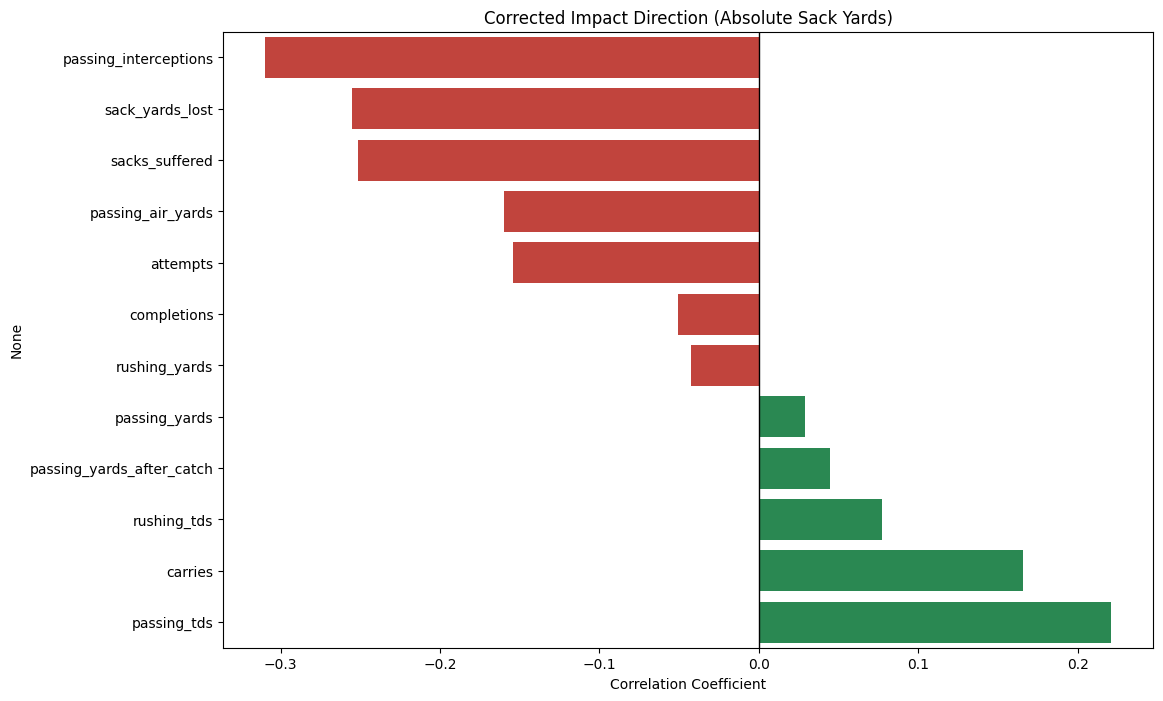

In [ ]:
import numpy as np

# Convert sack_yards_lost to absolute values in all relevant dataframes
# This makes it easier to interpret: higher value = more yards lost
ml_df['sack_yards_lost'] = ml_df['sack_yards_lost'].abs()
plot_train_df['sack_yards_lost'] = plot_train_df['sack_yards_lost'].abs()

# Recalculate the correlation with absolute values
new_corr = plot_train_df['sack_yards_lost'].corr(plot_train_df['win_numeric'])
print(f"New Correlation (Absolute Sack Yards Lost vs Winning): {new_corr:.4f}")

# Let's re-run the correlation plot to see the corrected direction
correlations_updated = plot_train_df[features + ['win_numeric']].corr()['win_numeric'].drop('win_numeric').sort_values()

plt.figure(figsize=(12, 8))
colors_updated = ['#d73027' if x < 0 else '#1a9850' for x in correlations_updated]
sns.barplot(x=correlations_updated.values, y=correlations_updated.index, palette=colors_updated)
plt.title('Corrected Impact Direction (Absolute Sack Yards)')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.show()